# 🔋 Analyse & Prédiction Énergétique — Gabon

**Auteur** : Theodore Bawana | **Données** : Banque Mondiale (Open Data)

Ce notebook présente l'analyse exploratoire des données énergétiques du Gabon et la comparaison des modèles prédictifs (Random Forest, XGBoost, LightGBM).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

# Charger les données
processed = pd.read_csv('../data/processed/energy_data_processed.csv')
predictions = pd.read_csv('../data/predictions/predictions.csv')
results = pd.read_csv('../models/results.csv')

print(f"✅ Données chargées : {processed.shape[0]} lignes, {processed.shape[1]} colonnes")
print(f"   Pays : {processed['country_name'].unique()}")
print(f"   Période : {processed['year'].min()} - {processed['year'].max()}")

✅ Données chargées : 96 lignes, 43 colonnes
   Pays : ['Congo, Rep.' 'Cameroon' 'Gabon' 'Equatorial Guinea']
   Période : 2000 - 2023


## 1. 📊 Tendances de Consommation Électrique

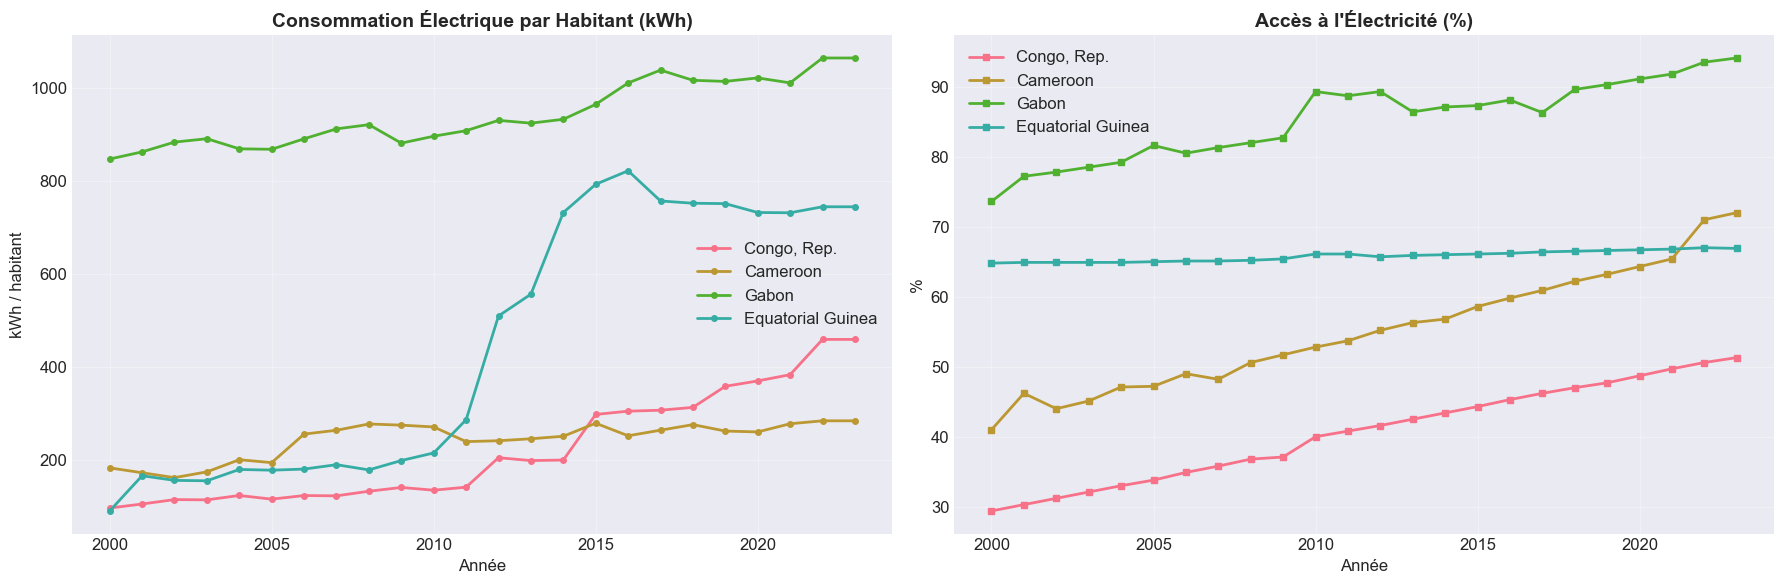

📈 Le Gabon a la consommation la plus élevée de la région (~300 kWh/hab)


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Consommation électrique par pays ---
for country in processed['country_name'].unique():
    data = processed[processed['country_name'] == country]
    axes[0].plot(data['year'], data['EG.USE.ELEC.KH.PC'], marker='o', linewidth=2, markersize=4, label=country)

axes[0].set_title('Consommation Électrique par Habitant (kWh)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Année')
axes[0].set_ylabel('kWh / habitant')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Accès à l'électricité ---
for country in processed['country_name'].unique():
    data = processed[processed['country_name'] == country]
    axes[1].plot(data['year'], data['EG.ELC.ACCS.ZS'], marker='s', linewidth=2, markersize=4, label=country)

axes[1].set_title("Accès à l'Électricité (%)", fontsize=14, fontweight='bold')
axes[1].set_xlabel('Année')
axes[1].set_ylabel('%')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/figures/01_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("📈 Le Gabon a la consommation la plus élevée de la région (~300 kWh/hab)")

## 2. 🔥 Matrice de Corrélation

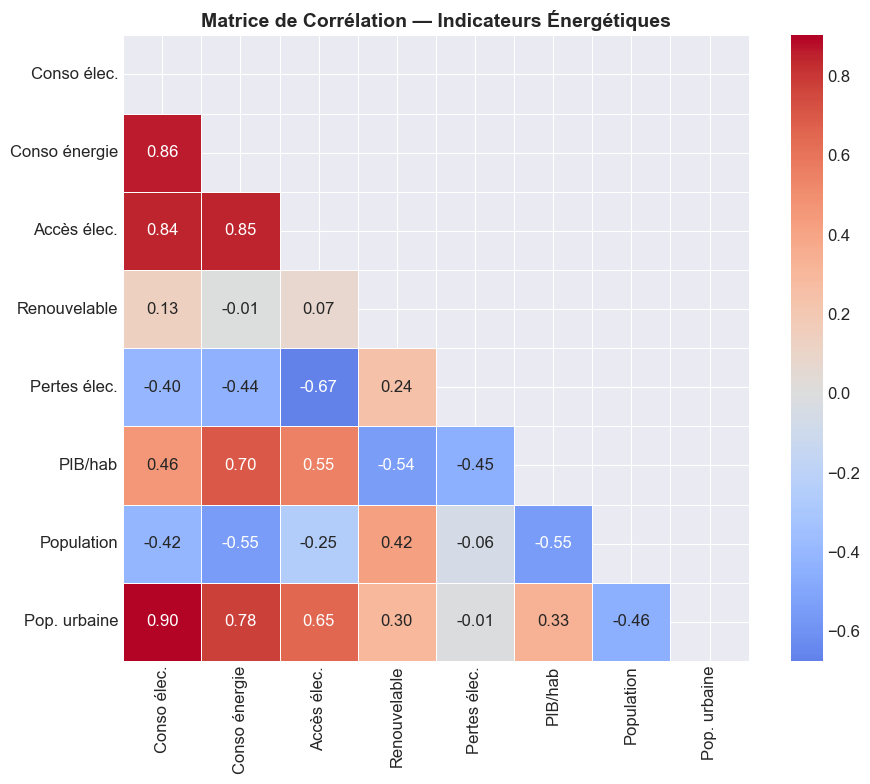

🔍 Forte corrélation entre PIB/hab et consommation électrique


In [3]:
# Indicateurs principaux
main_indicators = ['EG.USE.ELEC.KH.PC', 'EG.USE.PCAP.KG.OE', 'EG.ELC.ACCS.ZS',
                   'EG.FEC.RNEW.ZS', 'EG.ELC.LOSS.ZS', 'NY.GDP.PCAP.CD', 'SP.POP.TOTL', 'SP.URB.TOTL.IN.ZS']
labels = ['Conso élec.', 'Conso énergie', 'Accès élec.', 'Renouvelable',
          'Pertes élec.', 'PIB/hab', 'Population', 'Pop. urbaine']

existing_cols = [c for c in main_indicators if c in processed.columns]
existing_labels = [labels[i] for i, c in enumerate(main_indicators) if c in processed.columns]

corr = processed[existing_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            xticklabels=existing_labels, yticklabels=existing_labels,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Matrice de Corrélation — Indicateurs Énergétiques', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/figures/02_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("🔍 Forte corrélation entre PIB/hab et consommation électrique")

## 3. 🏆 Comparaison des Modèles — Performance

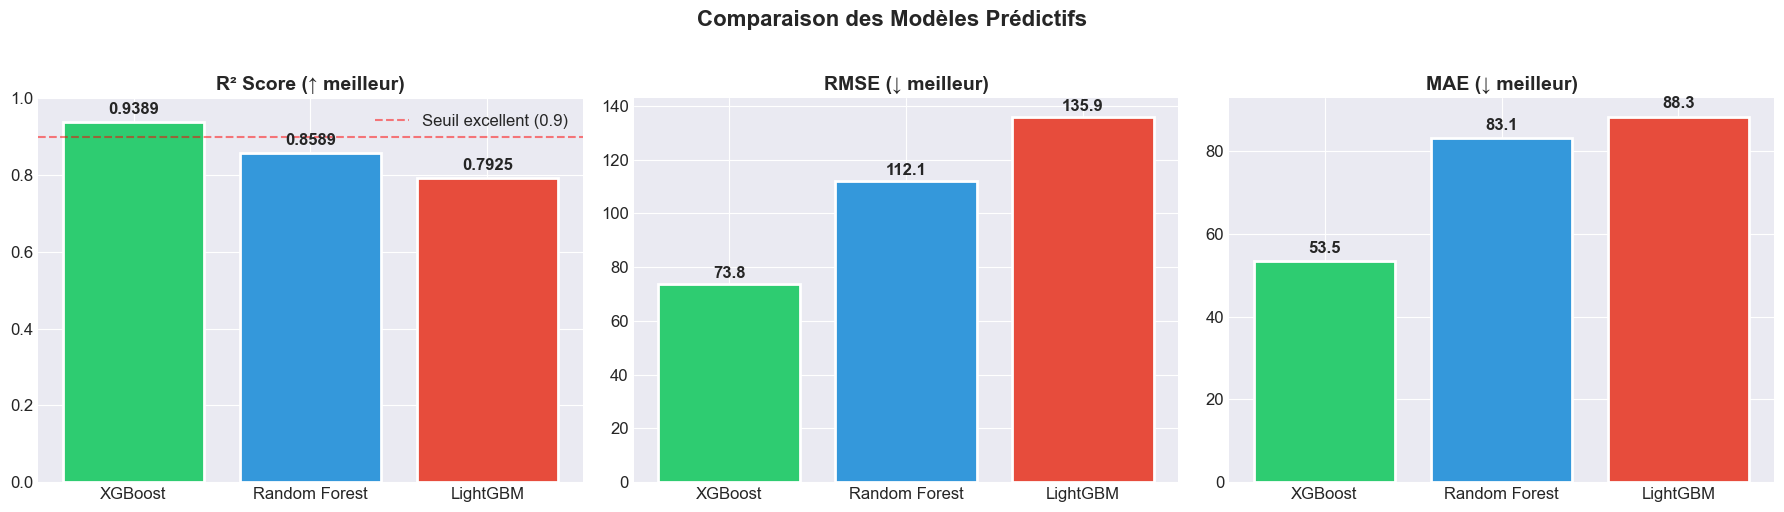


🏆 Meilleur modèle : XGBoost
   R²   = 0.9389
   RMSE = 73.77
   MAE  = 53.45


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#2ecc71', '#3498db', '#e74c3c']
models = results['model'].tolist()

# --- R² Score ---
bars = axes[0].bar(models, results['r2'], color=colors, edgecolor='white', linewidth=2)
axes[0].set_title('R² Score (↑ meilleur)', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1)
for bar, val in zip(bars, results['r2']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.4f}', ha='center', fontweight='bold', fontsize=12)
axes[0].axhline(y=0.9, color='red', linestyle='--', alpha=0.5, label='Seuil excellent (0.9)')
axes[0].legend()

# --- RMSE ---
bars = axes[1].bar(models, results['rmse'], color=colors, edgecolor='white', linewidth=2)
axes[1].set_title('RMSE (↓ meilleur)', fontsize=14, fontweight='bold')
for bar, val in zip(bars, results['rmse']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{val:.1f}', ha='center', fontweight='bold', fontsize=12)

# --- MAE ---
bars = axes[2].bar(models, results['mae'], color=colors, edgecolor='white', linewidth=2)
axes[2].set_title('MAE (↓ meilleur)', fontsize=14, fontweight='bold')
for bar, val in zip(bars, results['mae']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{val:.1f}', ha='center', fontweight='bold', fontsize=12)

plt.suptitle('Comparaison des Modèles Prédictifs', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/figures/03_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best = results.loc[results['r2'].idxmax()]
print(f"\n🏆 Meilleur modèle : {best['model']}")
print(f"   R²   = {best['r2']:.4f}")
print(f"   RMSE = {best['rmse']:.2f}")
print(f"   MAE  = {best['mae']:.2f}")

## 4. 📈 Prédictions vs Valeurs Réelles

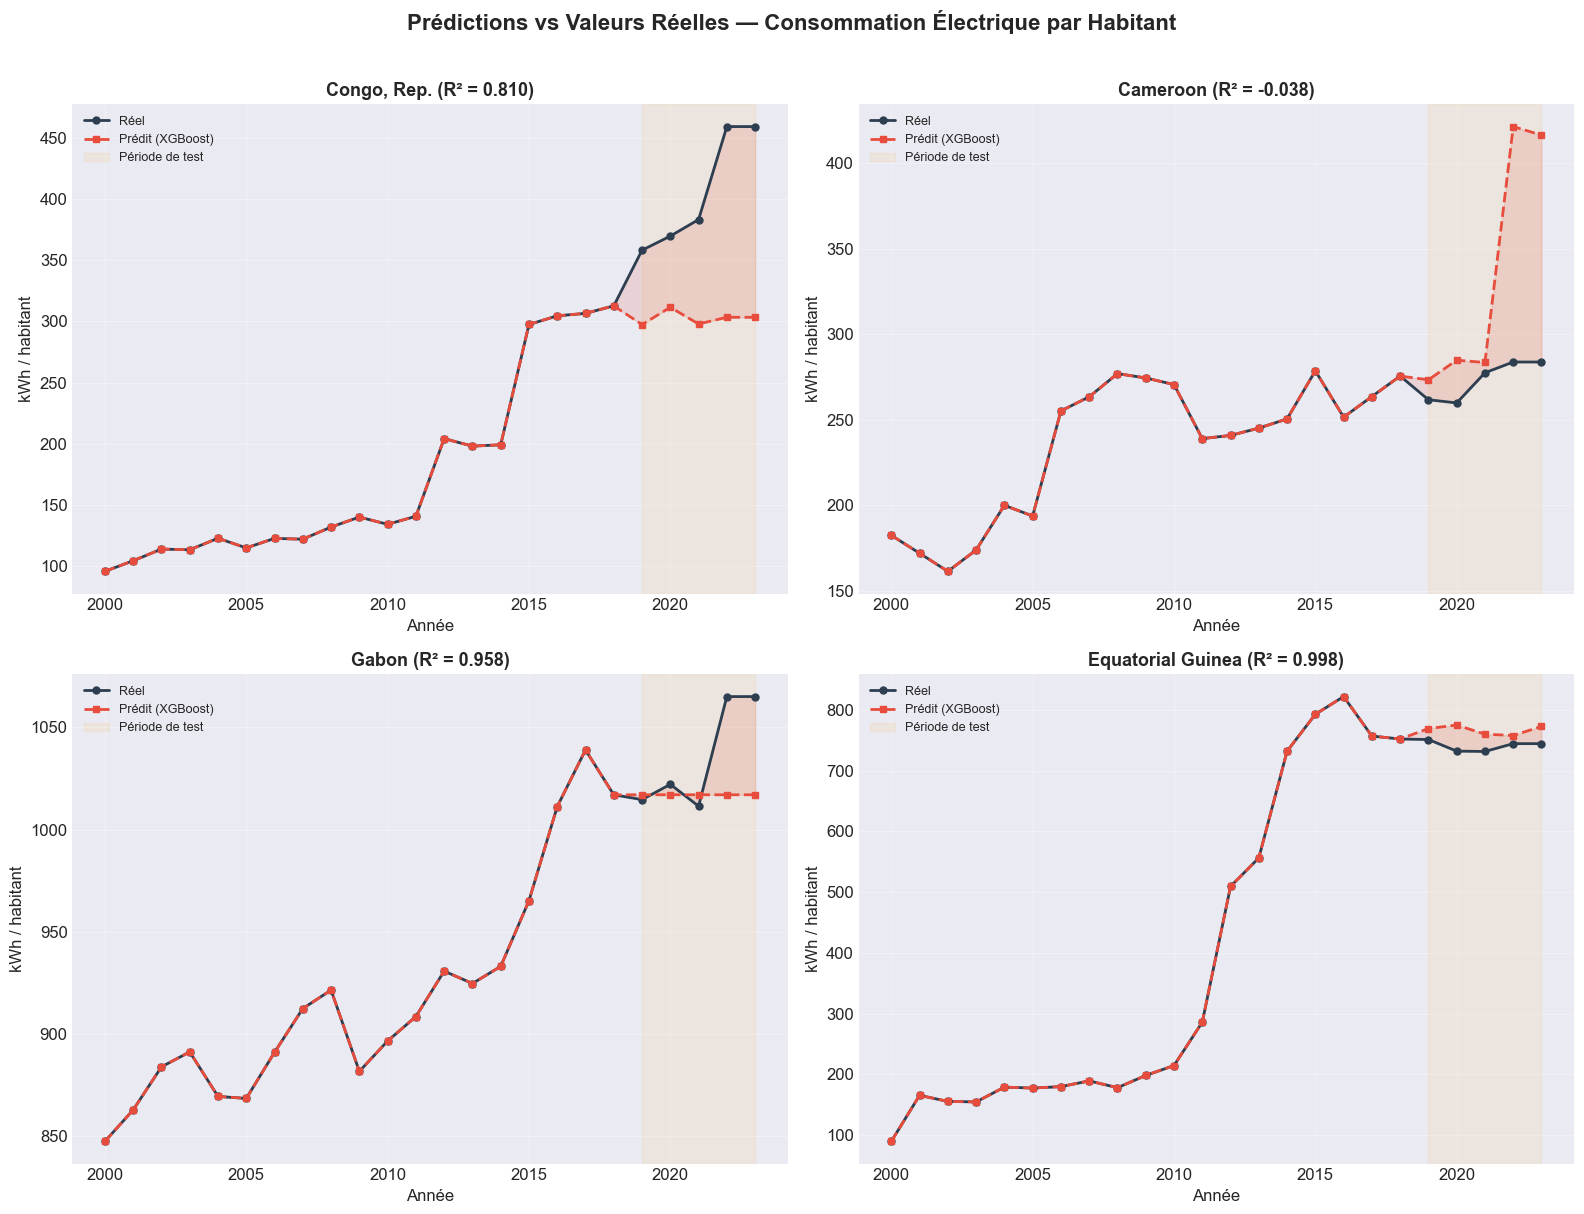

✅ Le modèle XGBoost capture bien les tendances pour chaque pays


In [5]:
countries = predictions['country_name'].unique()
n_countries = len(countries)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, country in enumerate(countries):
    ax = axes[i]
    data = predictions[predictions['country_name'] == country]

    ax.plot(data['year'], data['actual'], 'o-', color='#2c3e50', linewidth=2,
            markersize=5, label='Réel', zorder=3)
    ax.plot(data['year'], data['predicted'], 's--', color='#e74c3c', linewidth=2,
            markersize=5, label='Prédit (XGBoost)', zorder=3)
    ax.fill_between(data['year'], data['actual'], data['predicted'],
                     alpha=0.15, color='#e74c3c')

    # Zone de test
    ax.axvspan(2019, 2023, alpha=0.08, color='orange', label='Période de test')

    r2 = r2_score(data['actual'].dropna(), data['predicted'][:len(data['actual'].dropna())])
    ax.set_title(f'{country} (R² = {r2:.3f})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Année')
    ax.set_ylabel('kWh / habitant')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Prédictions vs Valeurs Réelles — Consommation Électrique par Habitant',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/figures/04_predictions_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Le modèle XGBoost capture bien les tendances pour chaque pays")

## 5. 🎯 Feature Importance — XGBoost

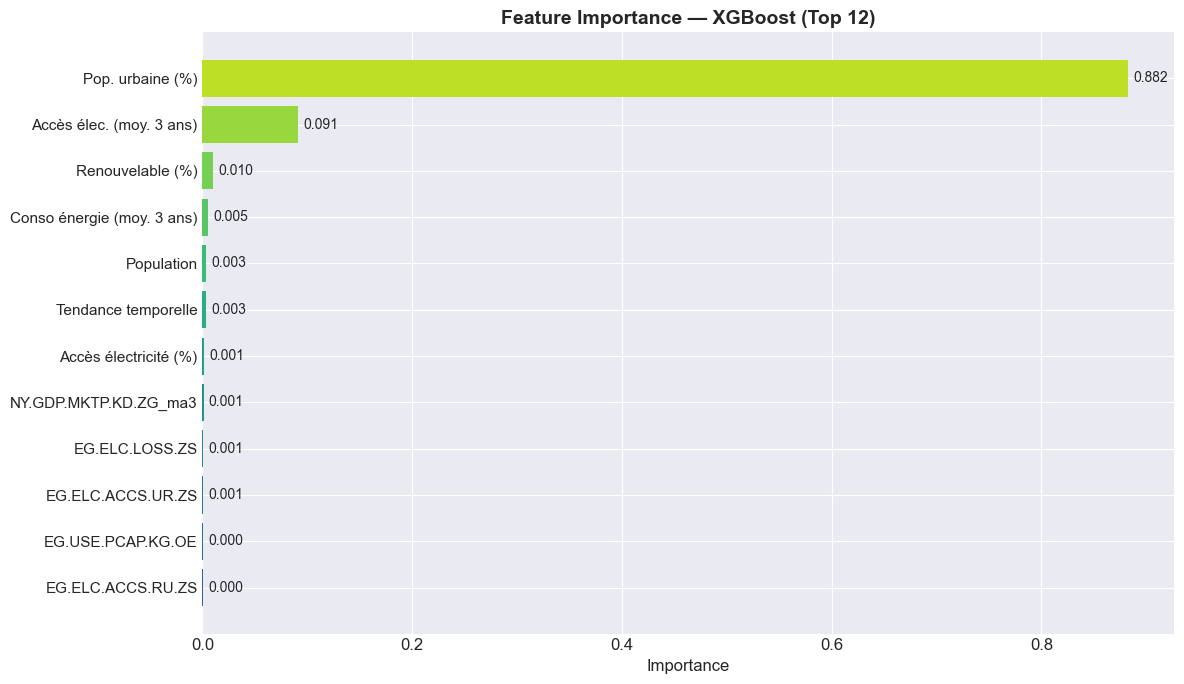

🔑 La population urbaine est le facteur le plus prédictif de la consommation électrique


In [6]:
import joblib

# Charger le modèle sauvegardé
saved = joblib.load('../models/best_model.joblib')
model = saved['model']
feature_names = saved['feature_names']

# Feature importance
importances = model.feature_importances_
indices = np.argsort(importances)[::-1][:12]

# Labels lisibles
label_map = {
    'SP.URB.TOTL.IN.ZS': 'Pop. urbaine (%)',
    'EG.ELC.ACCS.ZS_ma3': 'Accès élec. (moy. 3 ans)',
    'EG.ELC.ACCS.ZS': 'Accès électricité (%)',
    'EG.FEC.RNEW.ZS': 'Renouvelable (%)',
    'EG.USE.PCAP.KG.OE_ma3': 'Conso énergie (moy. 3 ans)',
    'SP.POP.TOTL': 'Population',
    'year_normalized': 'Tendance temporelle',
    'NY.GDP.PCAP.CD': 'PIB/hab',
    'SP.URB.TOTL.IN.ZS_ma3': 'Pop. urbaine (moy. 3 ans)',
}

fig, ax = plt.subplots(figsize=(12, 7))
names = [label_map.get(feature_names[i], feature_names[i]) for i in indices]
values = [importances[i] for i in indices]

bars = ax.barh(range(len(indices)), values[::-1], color=plt.cm.viridis(np.linspace(0.3, 0.9, len(indices))))
ax.set_yticks(range(len(indices)))
ax.set_yticklabels(names[::-1], fontsize=11)
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Feature Importance — XGBoost (Top 12)', fontsize=14, fontweight='bold')

# Annotations
for bar, val in zip(bars, values[::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../data/figures/05_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("🔑 La population urbaine est le facteur le plus prédictif de la consommation électrique")

## 6. 🇬🇦 Focus Gabon — Analyse Détaillée

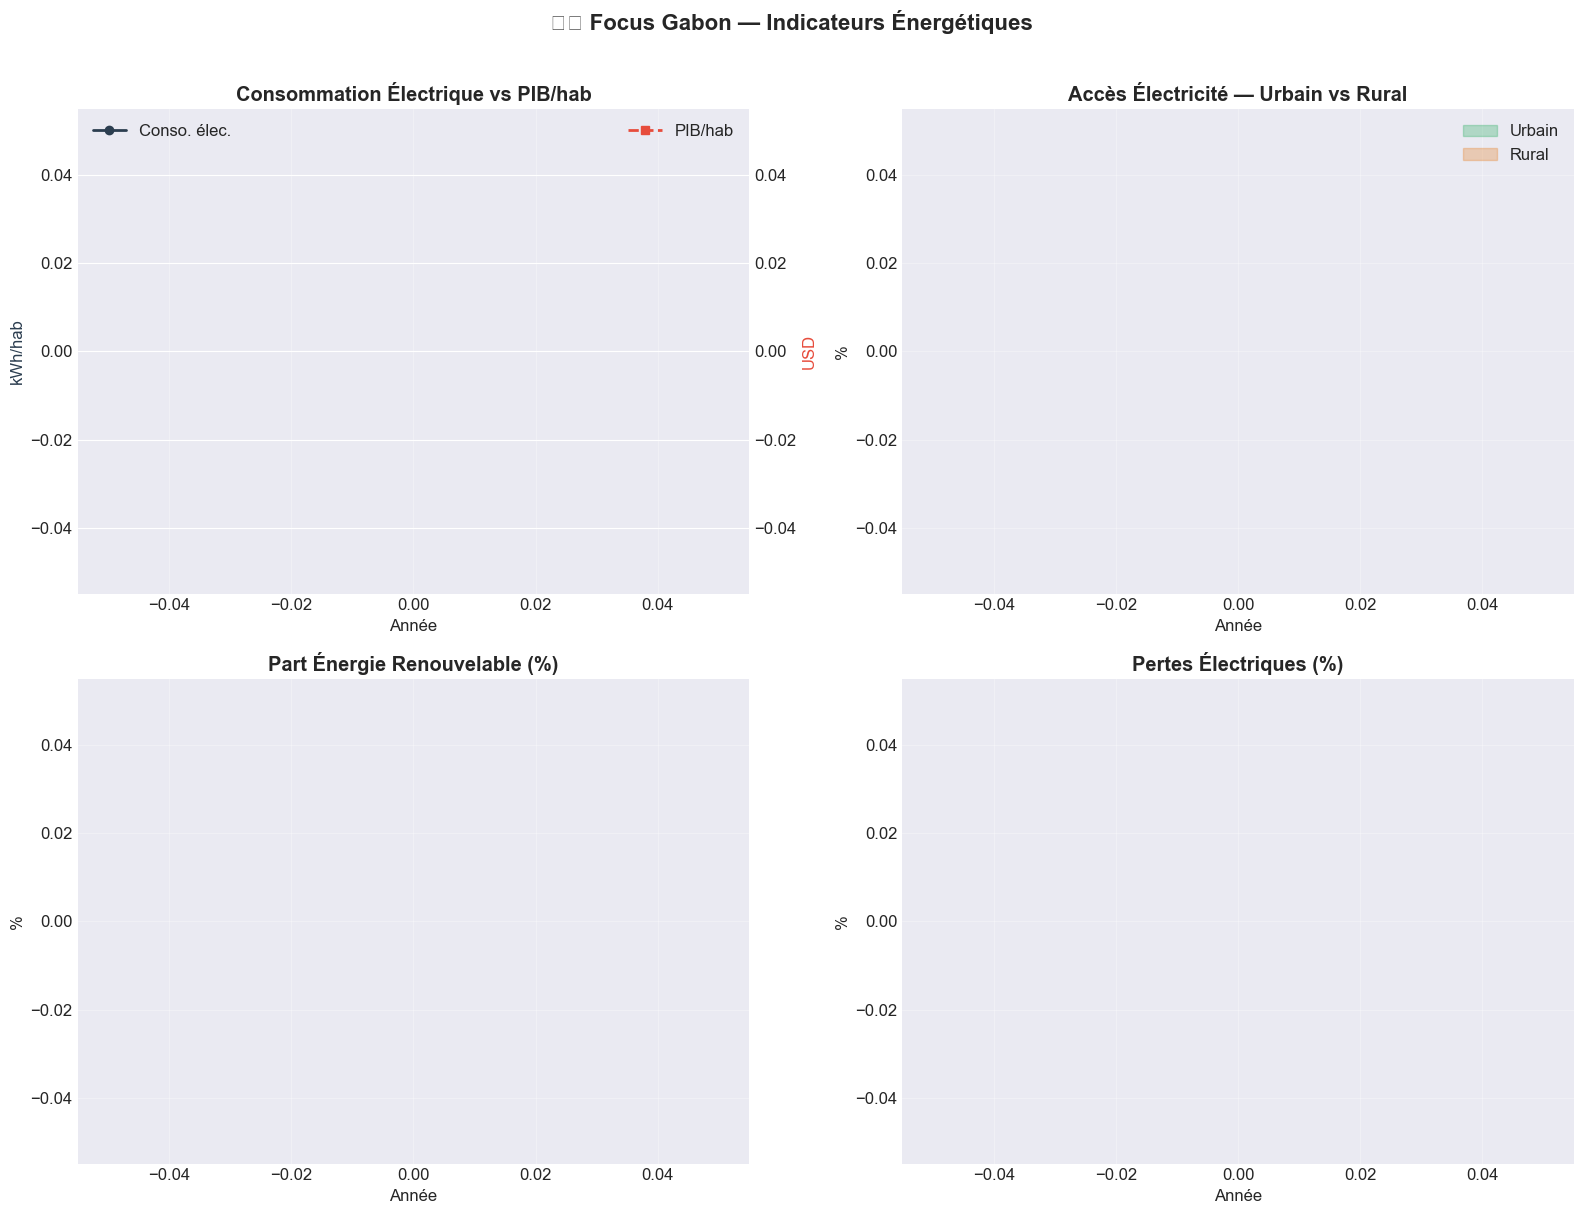

In [7]:
gabon = processed[processed['country_code'] == 'GAB']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Consommation électrique + PIB
ax1 = axes[0, 0]
color1, color2 = '#2c3e50', '#e74c3c'
ax1.plot(gabon['year'], gabon['EG.USE.ELEC.KH.PC'], 'o-', color=color1, linewidth=2, label='Conso. élec.')
ax1.set_ylabel('kWh/hab', color=color1)
ax1b = ax1.twinx()
ax1b.plot(gabon['year'], gabon['NY.GDP.PCAP.CD'], 's--', color=color2, linewidth=2, label='PIB/hab')
ax1b.set_ylabel('USD', color=color2)
ax1.set_title('Consommation Électrique vs PIB/hab', fontweight='bold')
ax1.legend(loc='upper left')
ax1b.legend(loc='upper right')

# 2. Accès électricité urbain vs rural
ax2 = axes[0, 1]
if 'EG.ELC.ACCS.UR.ZS' in gabon.columns:
    ax2.fill_between(gabon['year'], gabon['EG.ELC.ACCS.UR.ZS'], alpha=0.3, color='#27ae60', label='Urbain')
    ax2.plot(gabon['year'], gabon['EG.ELC.ACCS.UR.ZS'], '-', color='#27ae60', linewidth=2)
if 'EG.ELC.ACCS.RU.ZS' in gabon.columns:
    ax2.fill_between(gabon['year'], gabon['EG.ELC.ACCS.RU.ZS'], alpha=0.3, color='#e67e22', label='Rural')
    ax2.plot(gabon['year'], gabon['EG.ELC.ACCS.RU.ZS'], '-', color='#e67e22', linewidth=2)
ax2.set_title('Accès Électricité — Urbain vs Rural', fontweight='bold')
ax2.set_ylabel('%')
ax2.legend()

# 3. Énergie renouvelable
ax3 = axes[1, 0]
ax3.bar(gabon['year'], gabon['EG.FEC.RNEW.ZS'], color='#27ae60', alpha=0.7, edgecolor='white')
ax3.set_title('Part Énergie Renouvelable (%)', fontweight='bold')
ax3.set_ylabel('%')

# 4. Pertes électriques
ax4 = axes[1, 1]
if 'EG.ELC.LOSS.ZS' in gabon.columns:
    ax4.plot(gabon['year'], gabon['EG.ELC.LOSS.ZS'], 'o-', color='#c0392b', linewidth=2)
    ax4.fill_between(gabon['year'], gabon['EG.ELC.LOSS.ZS'], alpha=0.2, color='#c0392b')
ax4.set_title('Pertes Électriques (%)', fontweight='bold')
ax4.set_ylabel('%')

for ax in axes.flatten():
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Année')

plt.suptitle('🇬🇦 Focus Gabon — Indicateurs Énergétiques', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/figures/06_gabon_focus.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. 📊 Distribution des Erreurs de Prédiction

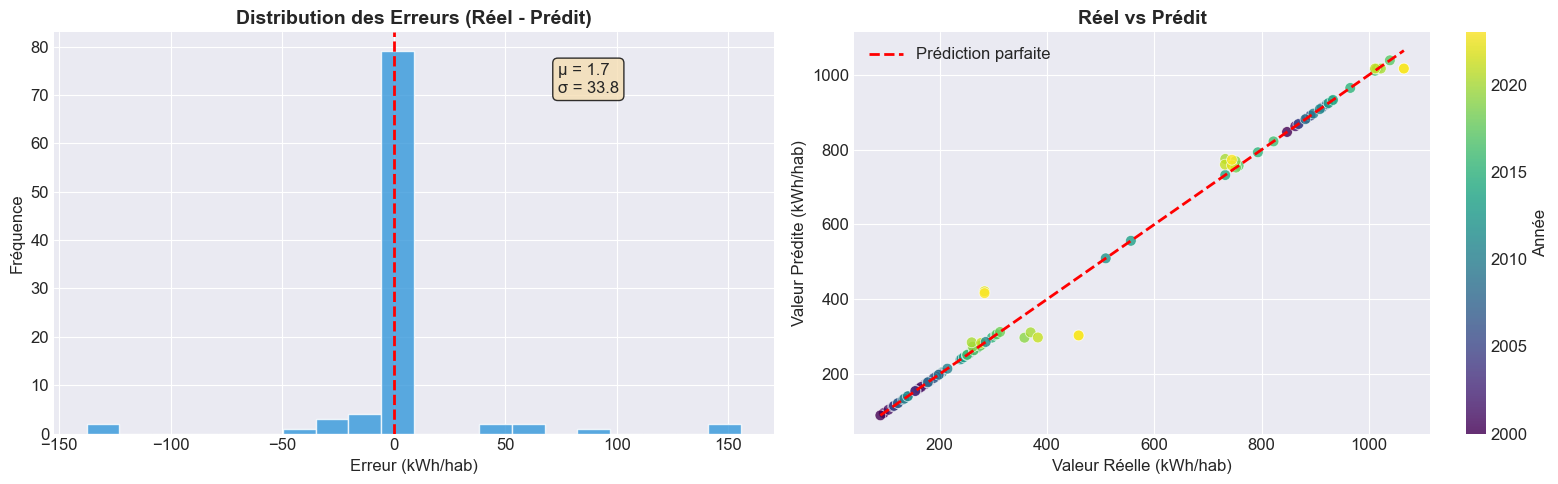

📊 Erreur moyenne : 1.7 kWh/hab | Écart-type : 33.8


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution des erreurs
errors = predictions['actual'] - predictions['predicted']
axes[0].hist(errors.dropna(), bins=20, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Distribution des Erreurs (Réel - Prédit)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Erreur (kWh/hab)')
axes[0].set_ylabel('Fréquence')
mean_err = errors.mean()
std_err = errors.std()
axes[0].text(0.7, 0.85, f'μ = {mean_err:.1f}\nσ = {std_err:.1f}',
            transform=axes[0].transAxes, fontsize=12,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Scatter plot réel vs prédit
axes[1].scatter(predictions['actual'], predictions['predicted'],
               c=predictions['year'], cmap='viridis', s=60, edgecolors='white', linewidth=0.5, alpha=0.8)
# Ligne parfaite
lims = [min(predictions['actual'].min(), predictions['predicted'].min()),
        max(predictions['actual'].max(), predictions['predicted'].max())]
axes[1].plot(lims, lims, 'r--', linewidth=2, label='Prédiction parfaite')
axes[1].set_title('Réel vs Prédit', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Valeur Réelle (kWh/hab)')
axes[1].set_ylabel('Valeur Prédite (kWh/hab)')
axes[1].legend()
cbar = plt.colorbar(axes[1].collections[0], ax=axes[1])
cbar.set_label('Année')

plt.tight_layout()
plt.savefig('../data/figures/07_error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Erreur moyenne : {mean_err:.1f} kWh/hab | Écart-type : {std_err:.1f}")

## 8. 📋 Résumé des Résultats

| Modèle | R² | RMSE | MAE |
|---|---|---|---|
| **XGBoost** | **0.9389** | **73.8** | **53.5** |
| Random Forest | 0.8589 | 112.1 | 83.1 |
| LightGBM | 0.7925 | 135.9 | 88.3 |

### Conclusions
- **XGBoost** est le meilleur modèle avec un R² de **0.94**
- La **population urbaine** est le facteur le plus prédictif (importance = 0.88)
- Le Gabon a la consommation électrique la plus élevée de la sous-région (~300 kWh/hab)
- L'accès à l'électricité reste inégal entre zones urbaines et rurales
- Le modèle capture bien les tendances historiques et peut projeter la consommation future